 ## Домашнее задание Проверка гипотез

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

<div class="alert alert-info">
<b>Задание № 1</b>
    
Разработайте функцию для проверки нормальности распределения выборки данных, используя шаблон ниже. Вы можете использовать один из известных Вам статистических тестов.
</div>

In [ ]:
def check_normality(data):
    statistic, p_value = stats.shapiro(data)
    
    if p_value < 0.05:
        print("Данные распределены не нормально")
    else:
        print("Данные распределены нормально")

<div class="alert alert-info">
<b>Задание № 2</b>

Даны две выборки роста мужчин и женщин.
- Докажите, используя `t-Тест Стьдента`, что различие между выборками незначительно, если уровень значимости равен $\alpha$ `= 0.001`.
- Покажите различия визуально
- Является ли результат полезным с практической точки зрения? Почему да или нет?
</div>

In [7]:
np.random.seed(42) #фиксация случайности

mens  = stats.norm.rvs(loc=171, scale=10, size=150000)  # Выборка мужчин со средним ростом 171
womens = stats.norm.rvs(loc=170, scale=10, size=150000)  # Выборка женщин со средним ростом 170

Отклоняем нулевую гипотезу >> Средний рост мужчин и женщин различается


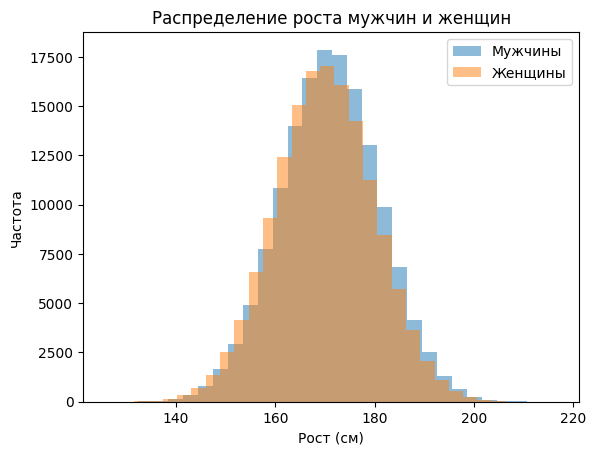

In [ ]:
statistic, p_value = stats.ttest_ind(mens, womens)

if p_value < 0.001:
    print("Средний рост мужчин и женщин различается")
else:
    print("Средний рост мужчин и женщин не различается")
    
plt.hist(mens, bins=30, alpha=0.5, label='Мужчины')
plt.hist(womens, bins=30, alpha=0.5, label='Женщины')
plt.legend()
plt.title('Распределение роста мужчин и женщин')
plt.xlabel('Рост (см)')
plt.ylabel('Частота')
plt.show()

Статистически значимо - да, но оно не отвечает на вопрос насколько это различие важно в реальности

<div class="alert alert-info">
<b>Задание № 3</b>

Специалист по кадрам, работающий в технологической компании, интересуется сверхурочным временем разных команд. Чтобы выяснить, есть ли разница между сверхурочной работой команды разработчиков программного обеспечения и группы тестирования, она случайным образом выбрала 17 сотрудников в каждой из двух команд и записала их среднее сверхурочное время за неделю в пересчете на час. Данные ниже.

В соответствии с этой информацией проведите проверку гипотезы, чтобы проверить, есть ли разница между переутомлением двух команд, используя уровень значимости 0,05. Прежде чем приступать к проверке гипотез, проверьте предположение нормальности.
</div>

In [19]:
test_team = [6.2, 7.1, 1.5, 2,3 , 2, 1.5, 6.1, 2.4, 2.3, 12.4, 1.8, 5.3, 3.1, 9.4, 2.3, 4.1]
developer_team = [2.3, 2.1, 1.4, 2.0, 8.7, 2.2, 3.1, 4.2, 3.6, 2.5, 3.1, 6.2, 12.1, 3.9, 2.2, 1.2 ,3.4]

In [ ]:
def normality_test(data):
    statistic, p_value = stats.shapiro(data)
    
    if p_value < 0.05:
        return print("Данные распределены не нормально")
    else:
        return print("Данные распределены нормально")

normality_test(test_team)
normality_test(developer_team)
    
statistic, p_value = stats.mannwhitneyu(test_team, developer_team)

if p_value < 0.05:
    print("Время тестировщиков и разработчиков различается")
else:    
    print("Время тестировщиков и разработчиков не различается")

Данные распределены не нормально
Данные распределены не нормально
Не отклоняем нулевую гипотезу >> Время тестировщиков и разработчиков не различается


<div class="alert alert-info">
<b>Задание № 4</b>

Педиатр хочет увидеть влияние потребления смеси на среднемесячную прибавку в весе у новорожденных. По этой причине она собрала данные из трех разных групп. Первая группа – дети исключительно грудного вскармливания, вторая группа – дети, которых кормят только смесью, и последняя группа – это дети, находящиеся на искусственном вскармливании и на грудном вскармливании. Эти данные приведены ниже.

В соответствии с этой информацией проведите проверку гипотезы, чтобы проверить, есть ли разница между среднемесячным приростом этих трех групп, используя уровень значимости 0,05. Если есть значительная разница, выполните дальнейший анализ, чтобы найти причину разницы.
</div>

In [22]:
only_breast = [794.1, 716.9, 993. , 724.7, 760.9, 908.2, 659.3 , 690.8, 768.7, 717.3 , 630.7, 729.5, 714.1, 810.3, 583.5, 679.9, 865.1];
only_formula = [898.8, 881.2, 940.2, 966.2, 957.5, 1061.7, 1046.2, 980.4, 895.6, 919.7, 1074.1, 952.5, 796.3, 859.6, 871.1 , 1047.5, 919.1 , 1160.5, 996.9];
both = [976.4, 656.4, 861.2, 706.8, 718.5, 717.1, 759.8, 894.6, 867.6, 805.6, 765.4, 800.3, 789.9, 875.3, 740. , 799.4, 790.3, 795.2 , 823.6, 818.7, 926.8, 791.7, 948.3];

Данные распределены нормально
Данные распределены нормально
Данные распределены нормально
Дисперсии в группах не различаются
Средние значения в группах различаются
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
   group1      group2    meandiff p-adj    lower    upper   reject
------------------------------------------------------------------
       both  only_breast -60.1286 0.0995 -129.1485   8.8912  False
       both only_formula 149.2636    0.0   82.3651 216.1621   True
only_breast only_formula 209.3923    0.0  137.3508 281.4337   True
------------------------------------------------------------------


/tmp/ipykernel_14167/1766530613.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([only_breast, only_formula, both],


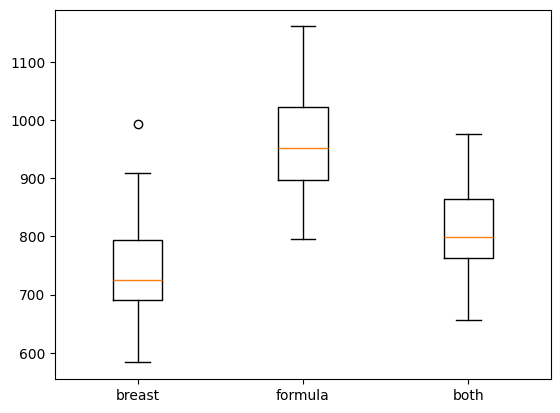

In [30]:
def normality_test(data):
    statistic, p_value = stats.shapiro(data)
    
    if p_value < 0.05:
        return print("Данные распределены не нормально")
    else:
        return print("Данные распределены нормально")
    
normality_test(only_breast)
normality_test(only_formula)
normality_test(both)

statistic, p_value = stats.levene(only_breast, only_formula, both)

if p_value < 0.05:
    print("Дисперсии в группах различаются")
else:    
    print("Дисперсии в группах не различаются")
    
statistic, p_value = stats.f_oneway(only_breast, only_formula, both)

if p_value < 0.05:
    print("Средние значения в группах различаются")
else:    
    print("Средние значения в группах не различаются")
    
data = np.array(only_breast + only_formula + both)
labels = (['only_breast'] * len(only_breast) + 
          ['only_formula'] * len(only_formula) + 
          ['both'] * len(both))

tukey_result = pairwise_tukeyhsd(data, labels)
print(tukey_result)

plt.boxplot([only_breast, only_formula, both],
            labels=["breast", "formula", "both"])
plt.show()